# Introduction to Data Science 2026

# Week 2

## Exercise 1 | Titanic: data preprocessing and imputation
<span style="font-weight: bold"> *Note: You can find tutorials for NumPy and Pandas under 'Useful tutorials' in the course material.*</span>

Download the [Titanic dataset](https://www.kaggle.com/c/titanic) [train.csv] from Kaggle or <span style="font-weight: 500">directly from the course material</span>, and complete the following exercises. If you choose to download the dataset from Kaggle, you will need to create a Kaggle account unless you already have one, but it is quite straightforward.

The dataset consists of personal information of all the passengers on board the RMS Titanic, along with information about whether they survived the iceberg collision or not.

1. Your first task is to read the data file and print the shape of the data.

    <span style="font-weight: 500"> *Hint 1: You can read them into a Pandas dataframe if you wish.*</span>
    
    <span style="font-weight: 500"> *Hint 2: The shape of the data should be (891, 12).*</span>

In [5]:
# Use this cell for your code
import pandas as pd
import numpy as np

data = pd.read_csv("train.csv")
print(data.shape)

(891, 12)


2. Let's look at the data and get started with some preprocessing. Some of the columns, e.g <span style="font-weight: 500"> *Name*</span>, simply identify a person and are not useful for prediction tasks. Try to identify these columns, and remove them.

    <span style="font-weight: 500"> *Hint: The shape of the data should now be (891, 9).*</span>

In [6]:
# Use this cell for your code
data = data.drop(columns=["PassengerId", "Name", "Ticket"])
print(data.shape)

(891, 9)


3. The column <span style="font-weight: 500">*Cabin*</span> contains a letter and a number. A smart catch at this point would be to notice that the letter stands for the deck level on the ship. Keeping just the deck information would be more informative when developing, e.g. a classifier that predicts whether a passenger survived. The next step in our preprocessing will be to add a new column to the dataset, which consists simply of the deck letter. You can then remove the original <span style="font-weight: 500">*Cabin*</span>-column.

<span style="font-weight: 500">*Hint: The deck letters should be ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T'].*</span>

In [7]:
# Use this cell for your code
data["Deck"] = data["Cabin"].str[0]
print(data["Deck"].dropna().unique())

data = data.drop(columns=["Cabin"])
print(data.shape)

['C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']
(891, 9)


4. You’ll notice that some of the columns, such as the previously added deck number, are [categorical](https://en.wikipedia.org/wiki/Categorical_variable). To preprocess the categorical variables so that they're ready for further computation, we need to avoid the current string format of the values. This means the next step for each categorical variable is to transform the string values to numeric ones, that correspond to a unique integer ID representative of each distinct category. This process is called label encoding and you can read more about it [here](https://pandas.pydata.org/docs/user_guide/categorical.html).

    <span style="font-weight: 500">*Hint: Pandas can do this for you.*</span>

In [8]:
# Use this cell for your code
categorical_cols = ["Sex", "Embarked", "Deck"]
category_mappings = {}

for col in categorical_cols:
    cat = data[col].astype("category")
    category_mappings[col] = dict(enumerate(cat.cat.categories))
    
    data[col] = (
        cat.cat.codes.astype(float)
        .where(data[col].notna(), np.nan)
    )

print(category_mappings)
print(data.head())

{'Sex': {0: 'female', 1: 'male'}, 'Embarked': {0: 'C', 1: 'Q', 2: 'S'}, 'Deck': {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'T'}}
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Deck
0         0       3  1.0  22.0      1      0   7.2500       2.0   NaN
1         1       1  0.0  38.0      1      0  71.2833       0.0   2.0
2         1       3  0.0  26.0      0      0   7.9250       2.0   NaN
3         1       1  0.0  35.0      1      0  53.1000       2.0   2.0
4         0       3  1.0  35.0      0      0   8.0500       2.0   NaN


5. Next, let's look into missing value **imputation**. Some of the rows in the data have missing values, e.g when the cabin number of a person is unknown. Most machine learning algorithms have trouble with missing values, and they need to be handled during preprocessing:

    a) For continuous variables, replace the missing values with the mean of the non-missing values of that column.

    b) For categorical variables, replace the missing values with the mode of the column.

    <span style="font-weight: 500">*Remember: Even though in the previous step we transformed categorical variables into their numeric representation, they are still categorical.*</span>

In [9]:
# Use this cell for your code
continuous_cols = ["Age", "Fare"]

categorical_cols = [
    "Sex",
    "Embarked",
    "Deck",
    "Pclass",
    "Survived"
]

for col in continuous_cols:
    data[col] = data[col].fillna(data[col].mean())

for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print(data.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Deck        0
dtype: int64


6. At this point, all data is numeric. Write the data, with the modifications we made, to a  <span style="font-weight: 500"> .csv</span> file. Then, write another file, this time in <span style="font-weight: 500">JSON</span> format, with the following structure:

In [6]:
#[
#    {
#        "Deck": 0,
#        "Age": 20,
#        "Survived", 0
#        ...
#    },
#    {
#        ...
#    }
#]

In [11]:
# Use this cell for your code
data.to_csv("titanic_preprocessed.csv", index=False)

data.to_json(
    "titanic_preprocessed.json",
    orient="records",
    indent=4
)

Study the records and try to see if there is any evident pattern in terms of chances of survival.

In [12]:
print("\nSurvival rate by sex:")
print(data.groupby("Sex")["Survived"].mean())

print("\nSurvival rate by passenger class:")
print(data.groupby("Pclass")["Survived"].mean())

print("\nAverage fare by survival:")
print(data.groupby("Survived")["Fare"].mean())


Survival rate by sex:
Sex
0.0    0.742038
1.0    0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Average fare by survival:
Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


# There're some clear patterns in the data. Female passengers had a much higher survival rate than male passengers. Passenger class also seems to have affected survival: first-class passengers had the highest survival rate, while third-class passengers had the lowest. Passengers who survived paid a higher fare on average. 
# Therefore, sex, passenger class and fare seem to be strongly related to the chance of survival.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Titanic 2.0: exploratory data analysis

In this exercise, we’ll continue to study the Titanic dataset from the last exercise. Now that we have done some preprocessing, it’s time to look at the data with some exploratory data analysis.

1. First investigate each feature variable in turn. For each categorical variable, find out the mode, i.e., the most frequent value. For numerical variables, calculate the median value.

In [13]:
# Use this cell for your code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = data.copy()

categorical_cols = ["Pclass", "Sex", "Embarked", "Deck"]
numerical_cols = ["Age", "SibSp", "Parch", "Fare"]

print("Modes of categorical variables:")
for col in categorical_cols:
    print(col, ":", df[col].mode()[0])

print("\nMedians of numerical variables:")
for col in numerical_cols:
    print(col, ":", df[col].median())

Modes of categorical variables:
Pclass : 3
Sex : 1.0
Embarked : 2.0
Deck : 2.0

Medians of numerical variables:
Age : 29.69911764705882
SibSp : 0.0
Parch : 0.0
Fare : 14.4542


2. Next, combine the modes of the categorical variables, and the medians of the numerical variables, to construct an imaginary “average survivor”. This "average survivor" should represent the typical passenger of the class of passengers who survived. Also following the same principle, construct the “average non-survivor”.

    <span style="font-weight: 500">*Hint 1: What are the average/most frequent variable values for a non-survivor?*</span>
    
    <span style="font-weight: 500">*Hint 2: You can split the dataframe in two: one subset containing all the survivors and one consisting of all the non-survivor instances. Then, you can use the summary statistics of each of these dataframe to create a prototype "average survivor" and "average non-survivor", respectively.*</span>

In [15]:
# Use this cell for your code
survivors = df[df["Survived"] == 1]
non_survivors = df[df["Survived"] == 0]


def make_average_passenger(group):
    passenger = {}
    for col in categorical_cols:
        passenger[col] = group[col].mode()[0]
    for col in numerical_cols:
        passenger[col] = group[col].median()
    return pd.Series(passenger)


average_survivor = make_average_passenger(survivors)
average_non_survivor = make_average_passenger(non_survivors)

print("Average survivor:")
print(average_survivor)

print("\nAverage non-survivor:")
print(average_non_survivor)

Average survivor:
Pclass       1.000000
Sex          0.000000
Embarked     2.000000
Deck         2.000000
Age         29.699118
SibSp        0.000000
Parch        0.000000
Fare        26.000000
dtype: float64

Average non-survivor:
Pclass       3.000000
Sex          1.000000
Embarked     2.000000
Deck         2.000000
Age         29.699118
SibSp        0.000000
Parch        0.000000
Fare        10.500000
dtype: float64


3. Next, let's study the distributions of the variables in the two groups (survivor/non-survivor). How well do the average cases represent the respective groups? Can you find actual passengers that are very similar to the (average) representative of their own group? Can you find passengers that are very similar to the (average) representative of the other group?

    <span style="font-weight: 500">*Note: Feel free to choose EDA methods according to your preference: non-graphical/graphical, static/interactive - anything goes.*</span>

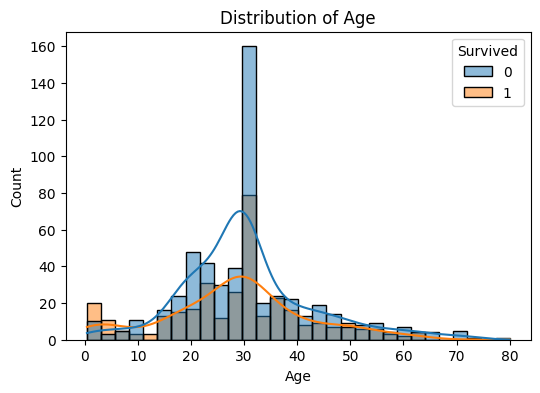

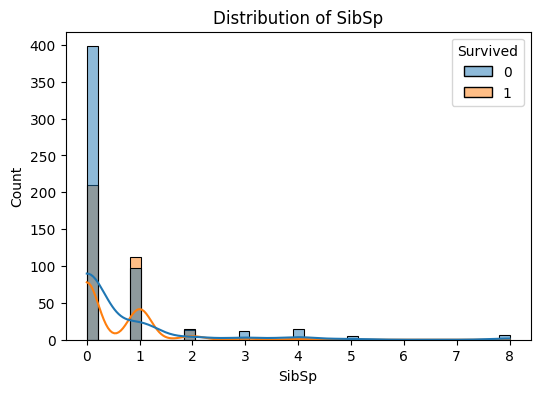

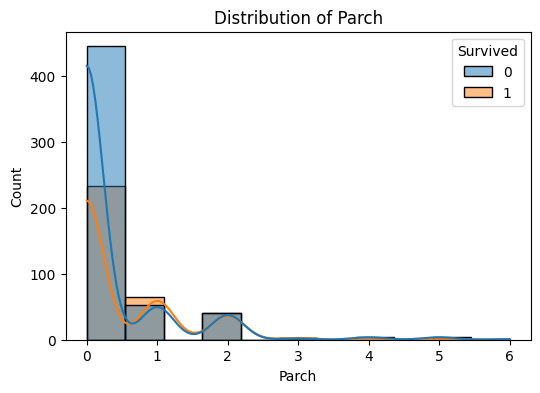

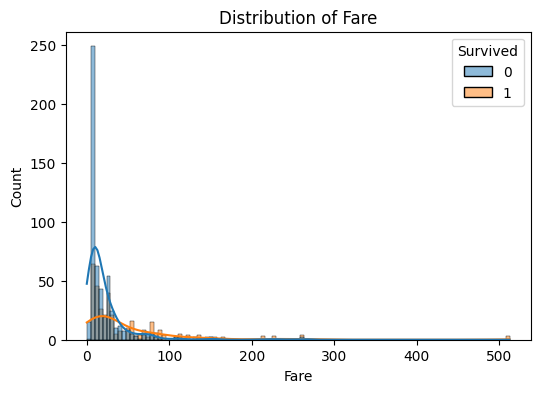

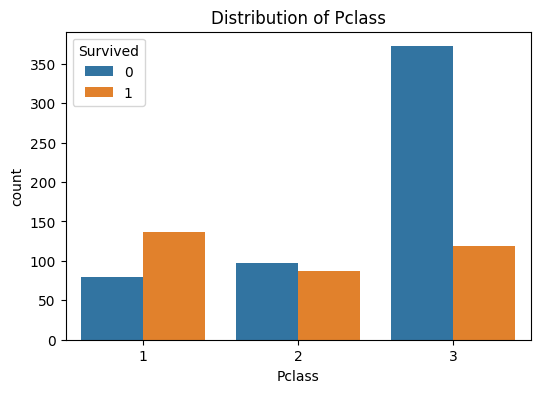

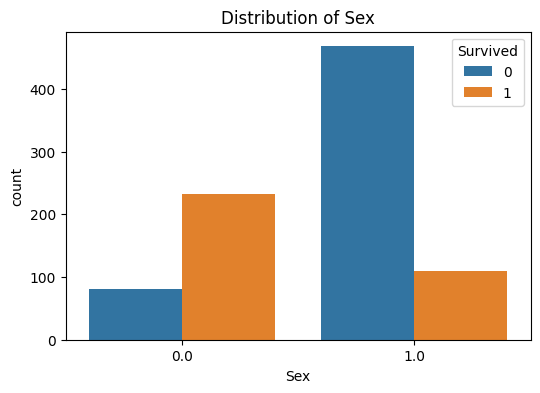

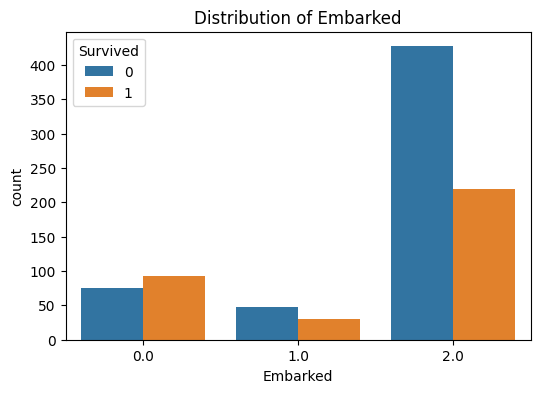

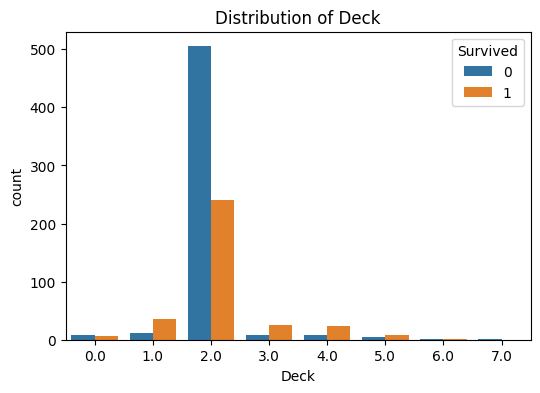

Average survivor:
Pclass       1.000000
Sex          0.000000
Embarked     2.000000
Deck         2.000000
Age         29.699118
SibSp        0.000000
Parch        0.000000
Fare        26.000000
dtype: float64

Average non-survivor:
Pclass       3.000000
Sex          1.000000
Embarked     2.000000
Deck         2.000000
Age         29.699118
SibSp        0.000000
Parch        0.000000
Fare        10.500000
dtype: float64

Survivors:
       Survived      Pclass         Sex         Age       SibSp       Parch  \
count     342.0  342.000000  342.000000  342.000000  342.000000  342.000000   
mean        1.0    1.950292    0.318713   28.549778    0.473684    0.464912   
std         0.0    0.863321    0.466660   13.772498    0.708688    0.771712   
min         1.0    1.000000    0.000000    0.420000    0.000000    0.000000   
25%         1.0    1.000000    0.000000   21.000000    0.000000    0.000000   
50%         1.0    2.000000    0.000000   29.699118    0.000000    0.000000   
75%         

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,distance_to_survivor,distance_to_non_survivor
507,1,1,1.0,29.699118,0,0,26.55,2.0,2.0,1.141271,16.174131
53,1,2,0.0,29.000000,1,0,26.00,2.0,2.0,1.577582,15.612135
133,1,2,0.0,29.000000,1,0,26.00,2.0,2.0,1.577582,15.612135
430,1,1,1.0,28.000000,0,0,26.55,2.0,2.0,2.046827,16.263133
801,1,2,0.0,31.000000,1,1,26.25,2.0,2.0,2.180549,15.929683


Survivors most similar to average non-survivor:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,distance_to_survivor,distance_to_non_survivor
286,1,3,1.0,30.000000,0,0,9.5000,2.0,2.0,16.653544,1.044285
81,1,3,1.0,29.000000,0,0,9.5000,2.0,2.0,16.665496,1.220150
79,1,3,0.0,30.000000,0,0,12.4750,2.0,2.0,13.675385,2.234089
444,1,3,1.0,29.699118,0,0,8.1125,2.0,2.0,18.026721,2.387500
797,1,3,0.0,31.000000,0,0,8.6833,2.0,2.0,17.480286,2.447998


Non-survivors most similar to average non-survivor:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,distance_to_non_survivor,distance_to_survivor
868,0,3,1.0,29.699118,0,0,9.5000,2.0,2.0,1.000000,16.650826
219,0,2,1.0,30.000000,0,0,10.5000,2.0,2.0,1.044285,15.567290
242,0,2,1.0,29.000000,0,0,10.5000,2.0,2.0,1.220150,15.580076
713,0,3,1.0,29.000000,0,0,9.4833,2.0,2.0,1.233874,16.682031
439,0,2,1.0,31.000000,0,0,10.5000,2.0,2.0,1.640821,15.618652


Non-survivors most similar to average survivor:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck,distance_to_non_survivor,distance_to_survivor
168,0,1,1.0,29.699118,0,0,25.9250,2.0,2.0,15.554119,1.002809
711,0,1,1.0,29.699118,0,0,26.5500,2.0,2.0,16.174131,1.141271
284,0,1,1.0,29.699118,0,0,26.0000,2.0,0.0,15.755951,2.236068
637,0,2,1.0,31.000000,1,1,26.2500,2.0,2.0,15.898264,2.398915
64,0,1,1.0,29.699118,0,0,27.7208,0.0,2.0,17.451532,2.821551



the average cases show some general differences between survivors and
non-survivors, especially in sex, passenger class and fare. However,
the distributions overlap, so the average cases do not represent every
passenger well. Some survivors resemble the average non-survivor and
some non-survivors resemble the average survivor.



In [20]:
# Use this cell for your code
# distributions of numerical variables
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df,
        x=col,
        hue="Survived",
        kde=True,
        alpha=0.5
    )
    plt.title(f"Distribution of {col}")
    plt.show()

# distributions of categorical variables
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=df,
        x=col,
        hue="Survived"
    )
    plt.title(f"Distribution of {col}")
    plt.show()



print("Average survivor:")
print(average_survivor)

print("\nAverage non-survivor:")
print(average_non_survivor)

print("\nSurvivors:")
print(survivors.describe())

print("\nNon-survivors:")
print(non_survivors.describe())

features = categorical_cols + numerical_cols

def distance(row, prototype):
    return np.sqrt(
        sum((row[col] - prototype[col]) ** 2 for col in features)
    )

survivors = survivors.copy()
non_survivors = non_survivors.copy()

survivors["distance_to_survivor"] = survivors.apply(
    lambda row: distance(row, average_survivor), axis=1
)

survivors["distance_to_non_survivor"] = survivors.apply(
    lambda row: distance(row, average_non_survivor), axis=1
)

non_survivors["distance_to_non_survivor"] = non_survivors.apply(
    lambda row: distance(row, average_non_survivor), axis=1
)

non_survivors["distance_to_survivor"] = non_survivors.apply(
    lambda row: distance(row, average_survivor), axis=1
)

print("Survivors most similar to average survivor:")
display(survivors.nsmallest(5, "distance_to_survivor"))

print("Survivors most similar to average non-survivor:")
display(survivors.nsmallest(5, "distance_to_non_survivor"))

print("Non-survivors most similar to average non-survivor:")
display(non_survivors.nsmallest(5, "distance_to_non_survivor"))

print("Non-survivors most similar to average survivor:")
display(non_survivors.nsmallest(5, "distance_to_survivor"))

print("""
the average cases show some general differences between survivors and
non-survivors, especially in sex, passenger class and fare. However,
the distributions overlap, so the average cases do not represent every
passenger well. Some survivors resemble the average non-survivor and
some non-survivors resemble the average survivor.
""")


4. Next, let's continue the analysis by looking into pairwise and multivariate relationships between the variables in the two groups. Try to visualize two variables at a time using, e.g., scatter plots and use a different color to encode the survival status.

    <span style="font-weight: 500">*Hint 1: You can also check out Seaborn's pairplot function, if you wish.*</span>

    <span style="font-weight: 500">*Hint 2: To better show many data points with the same value for a given variable, you can use either transparency or ‘jitter’.*</span>

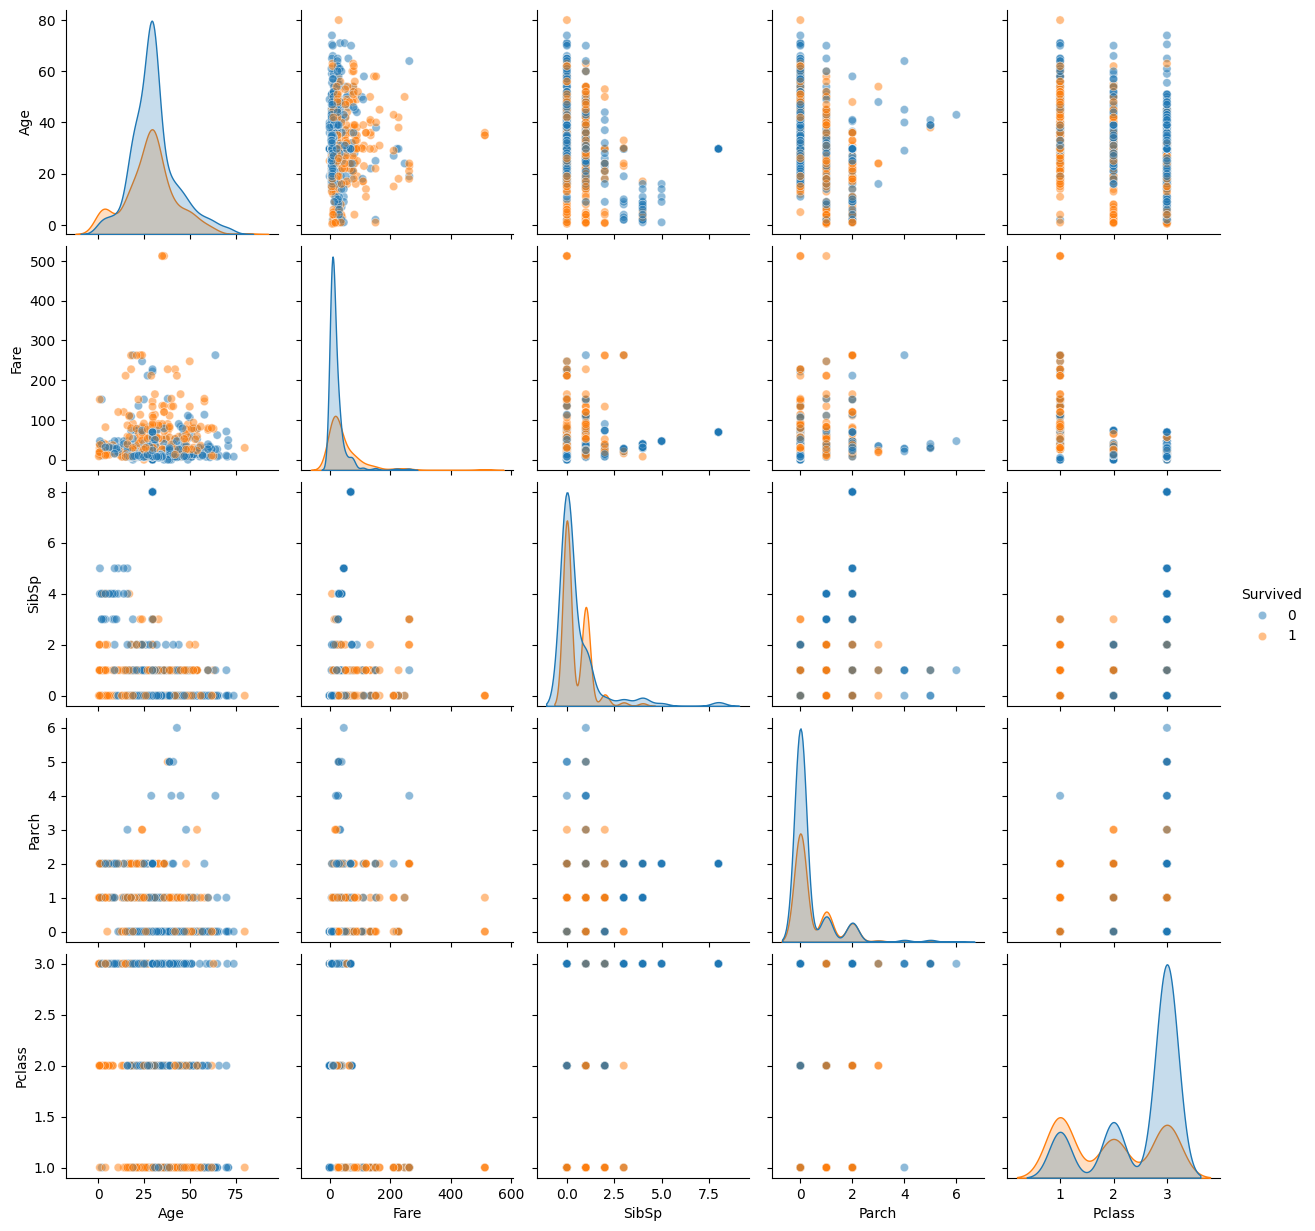

In [16]:
# Use this cell for your code
sns.pairplot(
    df,
    vars=["Age", "Fare", "SibSp", "Parch", "Pclass"],
    hue="Survived",
    plot_kws={"alpha": 0.5}
)

plt.show()

5. Finally, recall the preprocessing we did in the first exercise. What can you say about the effect of the choices that were made to use the mode and mean to impute missing values, instead of, for example, ignoring passengers with missing data?

*Use this (markdown) cell for your written answer*
# use mean and mode imputation allows us to keep all passengers in the dataset instead of removing rows with missing values. However, it can distort the original distributions by making some values appear more often and reducing variation. Ignoring rows with missing data avoids this distortion, but may result in losing a large amount of useful data.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | Working with text data 2.0

This exercise is related to the second exercise from last week. Find the saved <span style="font-weight: 500">pos.txt</span> and <span style="font-weight: 500">neg.txt</span> files, or, alternatively, you can find the week 1 example solutions on the MOOC platform after Tuesday.

1. Find the most common words in each file (positive and negative). Examine the results. Do they tend to be general terms relating to the nature of the data? How well do they indicate positive/negative sentiment?

In [30]:
# Use this cell for your code
from collections import Counter
import re

token_pattern = re.compile(r"(?u)\b\w\w+\b")

def count_words(filename):
    counts = Counter()
    with open(filename, "r", encoding="utf-8") as f:
        for line in f:
            words = token_pattern.findall(line.lower())
            counts.update(words)
    return counts

pos_counts = count_words("pos.txt")
neg_counts = count_words("neg.txt")

print("Most common words in positive reviews:")
print(pos_counts.most_common(20))

print("\nMost common words in negative reviews:")
print(neg_counts.most_common(20))


print("""Many common words, such as work, use, fit, and product, appear in both positive and negative reviews, 
so they are not very useful for identifying sentiment. However, positive reviews also contain words such as 
great and good, while negative reviews contain words such as return and didn't.
""")

Most common words in positive reviews:
[('great', 435906), ('work', 427780), ('use', 345233), ('good', 291448), ('fit', 273505), ('instal', 229408), ('product', 210084), ('look', 181401), ('just', 180420), ('like', 175725), ('easi', 162864), ('light', 147321), ('car', 147195), ('price', 144891), ('need', 136519), ('perfect', 124405), ('time', 123938), ('replac', 122261), ('qualiti', 119732), ('nice', 119314)]

Most common words in negative reviews:
[('work', 39998), ('use', 37244), ('fit', 31293), ('product', 24394), ('just', 23580), ('light', 22907), ('like', 20685), ('time', 19665), ('look', 18824), ('instal', 18709), ('did', 18446), ('good', 17295), ('dont', 17136), ('buy', 16885), ('car', 16694), ('return', 15227), ('tri', 14957), ('doe', 14201), ('replac', 13509), ('didnt', 13045)]
Many common words, such as work, use, fit, and product, appear in both positive and negative reviews, 
so they are not very useful for identifying sentiment. However, positive reviews also contain words

2. Compute a [TF/IDF](https://en.wikipedia.org/wiki/Tf–idf) vector for each of the two text files, and make them into a <span style="font-weight: 500">2 x m</span> matrix, where <span style="font-weight: 500">m</span> is the number of unique words in the data. The problem with using the most common words in a review to analyze its contents is that words that are common overall will be common in all reviews (both positive and negative). This means that they probably are not good indicators about the sentiment of a specific review. TF/IDF stands for Term Frequency / Inverse Document Frequency (here the reviews are the documents), and is designed to help by taking into consideration not just the number of times a term occurs (term frequency), but also how many times a word exists in other reviews as well (inverse document frequency). You can use any variant of the formula, as well as off-the-shelf implementations. <span style="font-weight: 500">*Hint: You can use [sklearn](http://scikit-learn.org/).*</span>

In [23]:
# Use this cell for your code
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(input="filename")
files = ["pos.txt", "neg.txt"]
tfidf_matrix = vectorizer.fit_transform(files)
words = vectorizer.get_feature_names_out()

print("Shape of TF-IDF matrix:", tfidf_matrix.shape)
print("Number of unique words:", len(words))

tfidf_matrix

Shape of TF-IDF matrix: (2, 149549)
Number of unique words: 149549


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 180048 stored elements and shape (2, 149549)>

3. List the words with the highest TF/IDF score in each class (positive | negative), and compare them to the most common words. What do you notice? Did TF/IDF work as expected?

In [32]:
# Use this cell for your code
import numpy as np
import pandas as pd

def top_tfidf(row, n=20):
    scores = tfidf_matrix.getrow(row).toarray().ravel()
    top_indices = np.argsort(scores)[-n:][::-1]
    
    return pd.DataFrame({
        "word": words[top_indices],
        "tfidf": scores[top_indices]
    })

top_positive = top_tfidf(0, 20)
top_negative = top_tfidf(1, 20)

print("Highest TF-IDF scores - positive:")
display(top_positive)

print("Highest TF-IDF scores - negative:")
display(top_negative)

print("""findings: the TF-IDF results are quite similar to the word-frequency results. Many high-scoring words occur in both classes, so 
TF-IDF does not clearly separate positive and negative reviews. This is probably because each whole file is treated as only one document.
""")

Highest TF-IDF scores - positive:


,word,tfidf
0,work,0.357722
1,great,0.339107
2,use,0.325940
3,good,0.237579
4,fit,0.219437
5,instal,0.182204
6,product,0.181521
7,just,0.155032
8,like,0.147361
9,easi,0.134543


Highest TF-IDF scores - negative:


,word,tfidf
0,work,0.301802
1,use,0.281022
2,fit,0.236119
3,product,0.184063
4,just,0.177921
5,light,0.172843
6,like,0.156077
7,time,0.148381
8,look,0.142035
9,instal,0.141168


findings: the TF-IDF results are quite similar to the word-frequency results. Many high-scoring words occur in both classes, so 
TF-IDF does not clearly separate positive and negative reviews. This is probably because each whole file is treated as only one document.



4. Plot the words in each class with their corresponding TF/IDF scores. Note that there will be a lot of words, so you’ll have to think carefully to make your chart clear! If you can’t plot them all, plot a subset – think about how you should choose this subset.

    <span style="font-weight: 500">*Hint: you can use word clouds. But feel free to challenge yourselves to think of any other meaningful way to visualize this information!*</span>

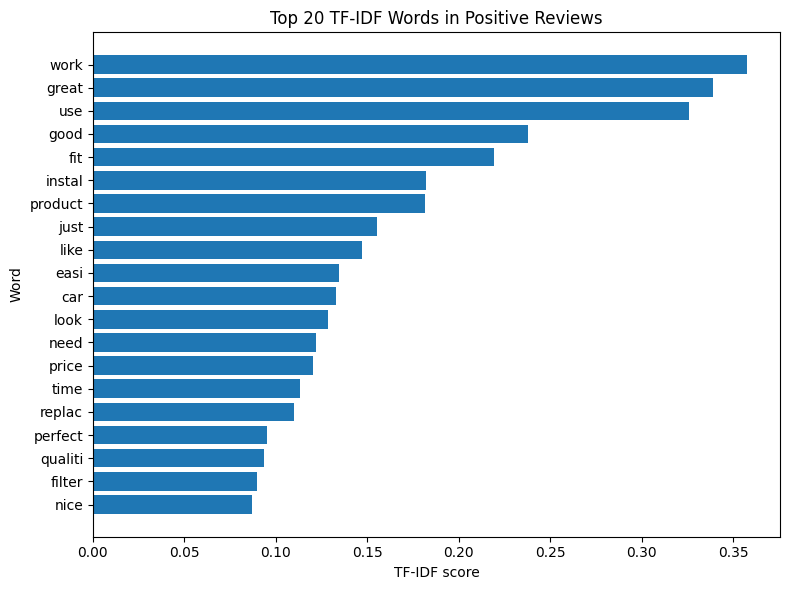

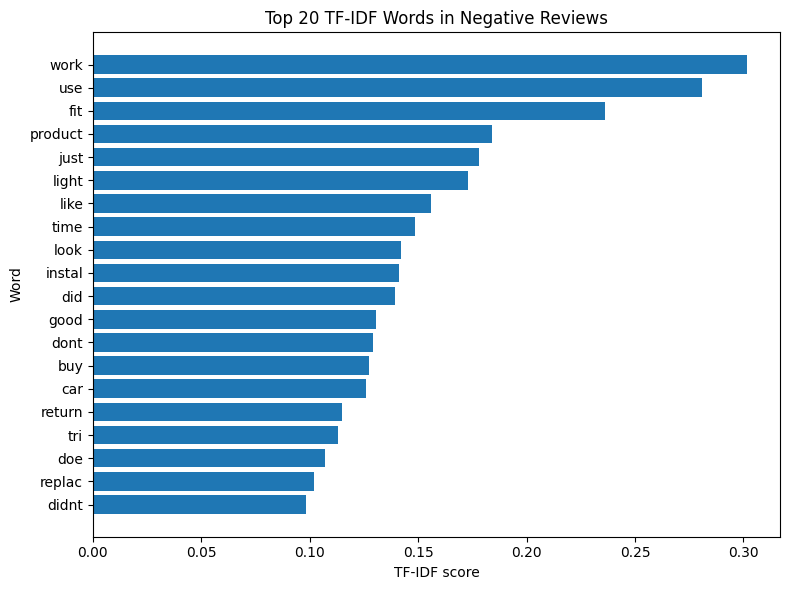

In [25]:
# Use this cell for your code
import matplotlib.pyplot as plt
import numpy as np

def plot_top_tfidf(row, title, n=20):
    scores = tfidf_matrix.getrow(row).toarray().ravel()
    top_indices = np.argsort(scores)[-n:]
    
    plt.figure(figsize=(8, 6))
    plt.barh(words[top_indices], scores[top_indices])
    plt.xlabel("TF-IDF score")
    plt.ylabel("Word")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_tfidf(0, "Top 20 TF-IDF Words in Positive Reviews")
plot_top_tfidf(1, "Top 20 TF-IDF Words in Negative Reviews")



**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**